In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import warnings
import os
from xarrayutils.plotting import linear_piecewise_scale
from dask.diagnostics import ProgressBar
from datetime import datetime
import sys
import cartopy.crs as ccrs

%matplotlib inline

import cftime
#import cmocean as cm
import cartopy.crs as ccrs

In [2]:
levels = 19

In [3]:
ds_input = xr.open_zarr("/Volumes/R1/Emulator/CM4_5daily_v0.4.0_preprocessed.zarr")

In [4]:
ds_input

<xarray.Dataset>
Dimensions:         (y: 180, x: 360, lev: 19, time: 14600, y_b: 181, x_b: 361)
Coordinates:
    areacello       (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(5, 90, 180), meta=np.ndarray>
  * time            (time) object 0151-01-06 00:00:00 ... 0351-01-01 00:00:00
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x               (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables:
    hfds            (time, y, x) float32 dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    so              (time, lev, y, x) float32 dask.array<chunksize=(10, 1, 180, 360), meta=np.ndarray>
    tauuo           (time, y, x) float32 dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    tauvo           (time, y, x) float32 dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
    thetao          (time, lev, y, x) float32 dask.array<chunksize=(10, 1, 180, 360), meta=np.ndarray>
    uo              (time, lev, y, x) float32 dask.array<chunksize=(10, 1, 180, 360), meta=np.ndarray>
    vo              (time, lev, y, x) float32 dask.array<chunksize=(10, 1, 180, 360), meta=np.ndarray>
    zos             (time, y, x) float32 dask.array<chunksize=(10, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [5]:
#ds_groundtruth = ds_input.isel(time=slice(13941, 13941 + 600)).isel(
#    lev=slice(None, levels)
#)
ds_groundtruth = ds_input

In [6]:
ds_groundtruth.hfds

<xarray.DataArray 'hfds' (time: 14600, y: 180, x: 360)>
dask.array<open_dataset-hfds, shape=(14600, 180, 360), dtype=float32, chunksize=(10, 180, 360), chunktype=numpy.ndarray>
Coordinates:
    areacello  (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat        (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon        (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
  * time       (time) object 0151-01-06 00:00:00 ... 0351-01-01 00:00:00
  * x          (x) float64 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5
  * y          (y) float64 -89.24 -88.25 -87.25 -86.26 ... 87.25 88.25 89.24

In [7]:
hfds = ds_groundtruth.hfds
hfds = hfds.drop_vars(["lon", "lat"])
#hfds = hfds.transpose("time", "lev", ...)
hfds["y"] = hfds.y.assign_attrs(long_name="latitude")
hfds["x"] = hfds.x.assign_attrs(long_name="longitude")
#hfds = hfds.rename({"y": "lat"})
#hfds = hfds.rename({"x": "lon"})
#hfds["lat"] = hfds.lat.assign_attrs(long_name="latitude")
#hfds["lon"] = hfds.lon.assign_attrs(long_name="longitude")

In [8]:
hfds

<xarray.DataArray 'hfds' (time: 14600, y: 180, x: 360)>
dask.array<open_dataset-hfds, shape=(14600, 180, 360), dtype=float32, chunksize=(10, 180, 360), chunktype=numpy.ndarray>
Coordinates:
    areacello  (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
  * time       (time) object 0151-01-06 00:00:00 ... 0351-01-01 00:00:00
  * x          (x) float64 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5
  * y          (y) float64 -89.24 -88.25 -87.25 -86.26 ... 87.25 88.25 89.24

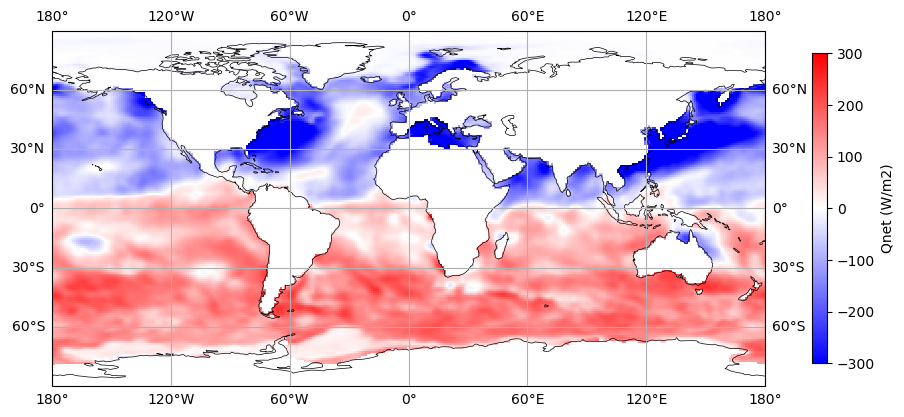

In [9]:
# Create a map
fig, ax = plt.subplots(
    figsize=(10, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
#ax.set_extent([0, 360, -90, 90], crs=ccrs.PlateCarree())

vmin, vmax = -300, 300

# Add coastlines and gridlines
ax.coastlines(resolution="110m", linewidth=0.5)
#ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=True)
c = plt.pcolormesh(hfds.x, hfds.y, hfds[0,:,:], cmap="bwr", vmin=vmin, vmax=vmax)
cbar = plt.colorbar(c, ax=ax, orientation="vertical", fraction=0.02, pad=0.06) 
cbar.set_label("Qnet (W/m2)", fontsize=10)
plt.show()

In [10]:
data = ds_groundtruth

In [11]:
def process_mask(mask):
    mask = mask.where(mask != 0, np.nan)
    mask = mask.transpose("lat", "lon")
    mask = mask.assign_coords(lat=data.y.values, lon=data.x.values)
    mask = mask.rename({"lat": "y", "lon": "x"})
    return mask

atlantic_mask0 = xr.open_dataset("/Users/ray/Oceanography/Research/data.process/grid/basin_At_noArctic.nc")["basin"]
atlantic_mask = atlantic_mask0.where(atlantic_mask0["lat"] >= -32)
atlantic_mask = process_mask(atlantic_mask)
pacific_mask0 = xr.open_dataset("/Users/ray/Oceanography/Research/data.process/grid/basin_Pa.nc")["basin"]
pacific_mask = pacific_mask0.where(pacific_mask0["lat"] >= -32)
pacific_mask = process_mask(pacific_mask)
indian_ocean_mask0 = xr.open_dataset("/Users/ray/Oceanography/Research/data.process/grid/basin_In.nc")["basin"]
indian_ocean_mask = indian_ocean_mask0.where(indian_ocean_mask0["lat"] >= -32)
indian_ocean_mask = process_mask(indian_ocean_mask)
southern_ocean_mask0 = xr.open_dataset("/Users/ray/Oceanography/Research/data.process/grid/basin_SO_32S.nc")["basin"]
#southern_ocean_mask = southern_ocean_mask0.where(southern_ocean_mask0["lat"] >= -32)
southern_ocean_mask = process_mask(southern_ocean_mask0)
arctic_mask0 = xr.open_dataset("/Users/ray/Oceanography/Research/data.process/grid/basin_Arctic.nc")["basin"]
arctic_mask = process_mask(arctic_mask0)

masks = xr.Dataset(
    {
        "Atlantic": atlantic_mask,
        "Pacific": pacific_mask,
        "Southern": southern_ocean_mask,
        "Indian": indian_ocean_mask,
        "Arctic": arctic_mask,
    }
)

In [12]:
def remove_climatology(ds):
    # Compute the climatology on the detrended data
    climatology = ds.groupby("time.dayofyear").mean("time").compute()

    # Remove the seasonal cycle (climatology) from the detrended data
    day_of_year = ds["time"].dt.dayofyear
    res = (ds - climatology.sel(dayofyear=day_of_year)).compute()

    return res

In [13]:
hfds_ano = remove_climatology(hfds)

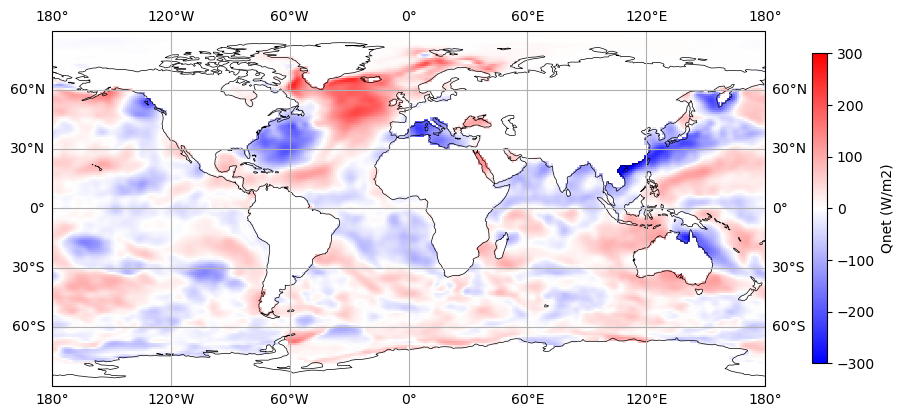

In [14]:
# Create a map
fig, ax = plt.subplots(
    figsize=(10, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
#ax.set_extent([0, 360, -90, 90], crs=ccrs.PlateCarree())

vmin, vmax = -300, 300

# Add coastlines and gridlines
ax.coastlines(resolution="110m", linewidth=0.5)
#ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=True)
c = plt.pcolormesh(hfds.x, hfds.y, hfds_ano[0,:,:], cmap="bwr", vmin=vmin, vmax=vmax)
cbar = plt.colorbar(c, ax=ax, orientation="vertical", fraction=0.02, pad=0.06) 
cbar.set_label("Qnet (W/m2)", fontsize=10)
plt.show()

In [15]:
hfds_ano

<xarray.DataArray 'hfds' (time: 14600, y: 180, x: 360)>
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 1.902468  ,  1.8616211 ,  1.8179352 , ...,  2.018548  ,
          1.9813058 ,  1.9422681 ],
        [ 2.807107  ,  2.8011894 ,  2.795168  , ...,  2.8083818 ,
          2.8083906 ,  2.8089926 ],
        [ 2.2430239 ,  2.2595675 ,  2.274238  , ...,  2.19363   ,
          2.2121964 ,  2.2282293 ]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [-0.33871865, -0.283844  , -0.22547197, ..., -0.48751068,
         -0.44198895, -0.3915274 ],
        [-2.1118302 , -2.0587316 , -2.0012455 , ..., -2.2277627 ,
         -2.1949801 , -2.1576657 ],
        [-2.1885414 , -2.2123094 , -2.2345839 , ..., -2.1069822 ,
         -2.1359963 , -2.163323  ]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [ 3.0056434 ,  3.0661972 ,  3.123692  , ...,  2.797871  ,
          2.87001   ,  2.940072  ],
        [ 2.712253  ,  2.774095  ,  2.833986  , ...,  2.5090723 ,
          2.5786462 ,  2.645825  ],
        [ 1.9143524 ,  1.924479  ,  1.9329516 , ...,  1.8879071 ,
          1.8982393 ,  1.906489  ]]], dtype=float32)
Coordinates:
    areacello  (y, x) float64 1.699e+08 1.699e+08 ... 1.699e+08 1.699e+08
  * time       (time) object 0151-01-06 00:00:00 ... 0351-01-01 00:00:00
  * x          (x) float64 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5
  * y          (y) float64 -89.24 -88.25 -87.25 -86.26 ... 87.25 88.25 89.24
    dayofyear  (time) int64 6 11 16 21 26 31 36 41 ... 336 341 346 351 356 361 1

In [16]:
hfds_ano_zmean = hfds_ano.weighted(data["areacello"]).mean(["x"]) #.transpose()

In [17]:
hfds_ano_zmean

<xarray.DataArray 'hfds' (time: 14600, y: 180)>
dask.array<truediv, shape=(14600, 180), dtype=float64, chunksize=(517, 90), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) object 0151-01-06 00:00:00 ... 0351-01-01 00:00:00
  * y          (y) float64 -89.24 -88.25 -87.25 -86.26 ... 87.25 88.25 89.24
    dayofyear  (time) int64 6 11 16 21 26 31 36 41 ... 336 341 346 351 356 361 1

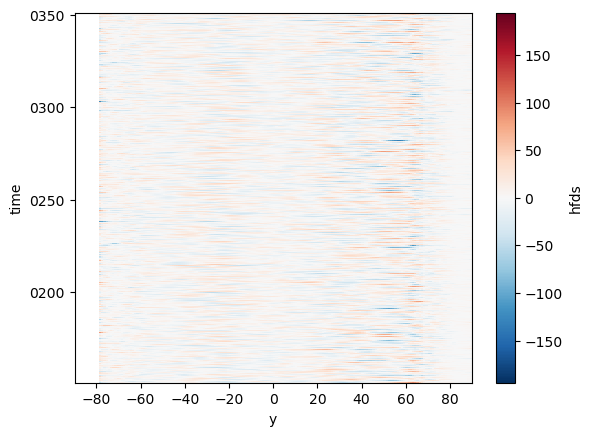

In [18]:
hfds_ano_zmean.plot() #(cmap="coolwarm", vmin=-50, vmax=50)
plt.show()

In [28]:
hfds_ano_zmean_smooth = hfds_ano_zmean.rolling(time=21, center=True).mean()

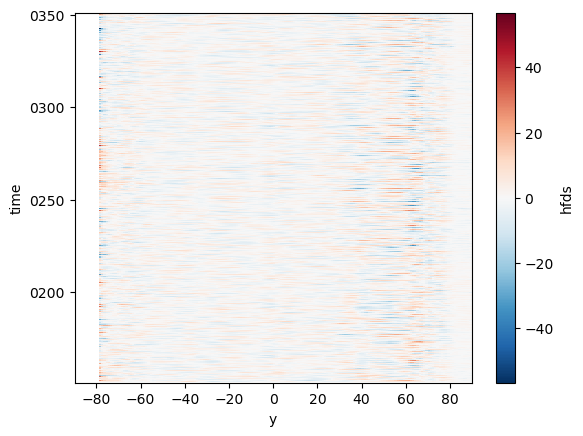

In [29]:
hfds_ano_zmean_smooth.plot() #(cmap="coolwarm", vmin=-50, vmax=50)
plt.show()

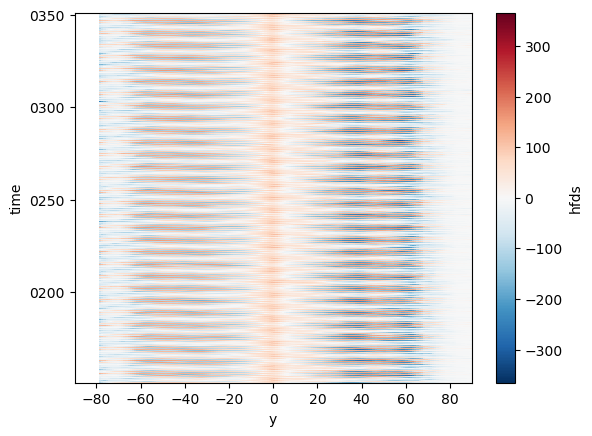

In [21]:
hfds_zmean = hfds.weighted(data["areacello"]).mean(["x"]) #.transpose()
hfds_zmean.plot()
plt.show()

In [22]:
hfds_global_witharea = hfds_ano * data["areacello"] 
hfds_global_mean = hfds_global_witharea.sum(["x","y"])/data["areacello"].sum(["x","y"])

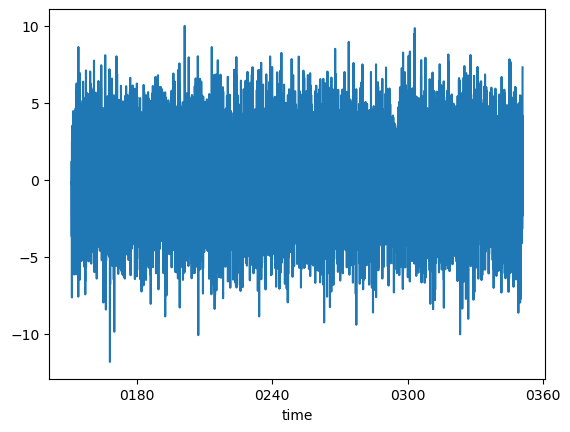

In [23]:
hfds_global_mean.plot()
plt.show()

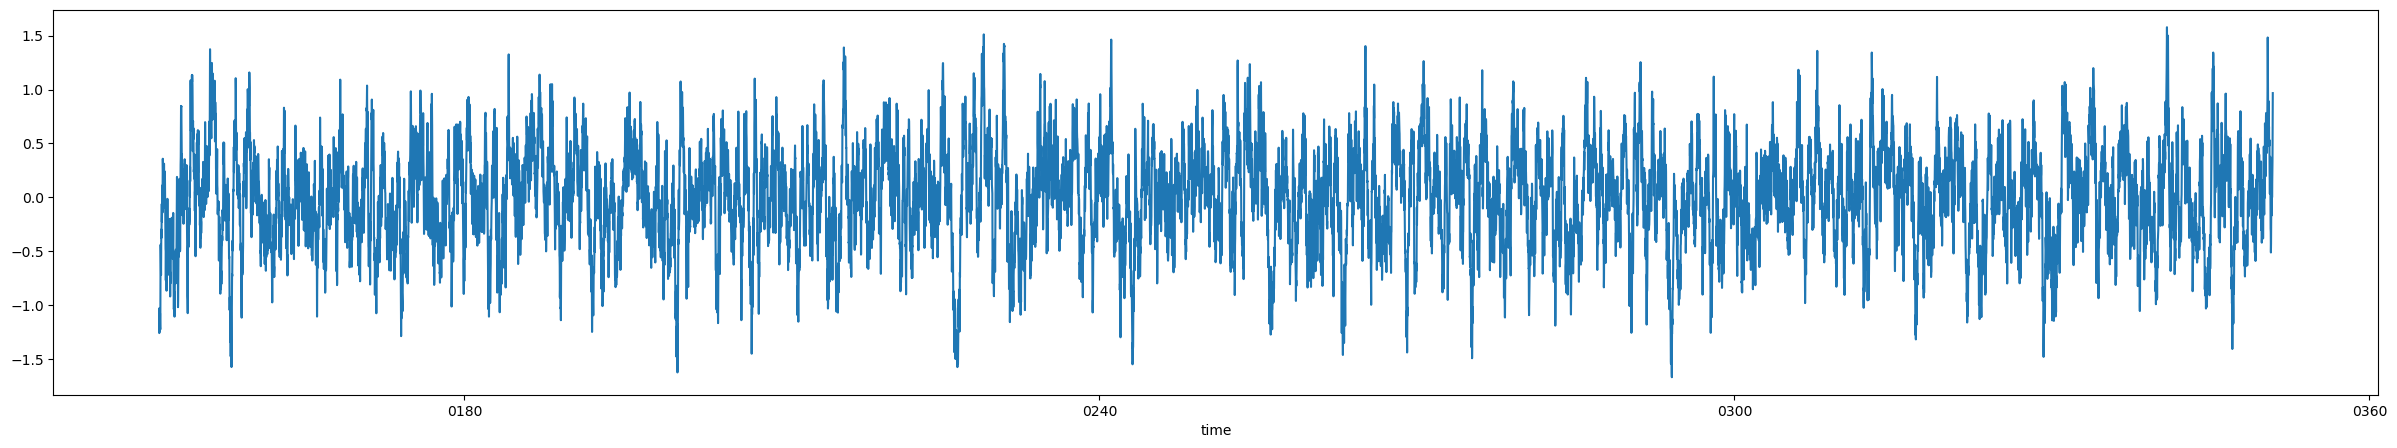

In [27]:
plt.figure(figsize=(30, 5)) 
hfds_global_mean.rolling(time=21, center=True).mean().plot()
plt.show()

In [30]:
tauuo = ds_groundtruth.tauuo
tauuo = tauuo.drop_vars(["lon", "lat"])
#tauuo = tauuo.transpose("time", "lev", ...)
tauuo["y"] = tauuo.y.assign_attrs(long_name="latitude")
tauuo["x"] = tauuo.x.assign_attrs(long_name="longitude")

In [31]:
ds_groundtruth.tauuo

<xarray.DataArray 'tauuo' (time: 14600, y: 180, x: 360)>
dask.array<open_dataset-tauuo, shape=(14600, 180, 360), dtype=float32, chunksize=(10, 180, 360), chunktype=numpy.ndarray>
Coordinates:
    areacello  (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat        (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon        (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
  * time       (time) object 0151-01-06 00:00:00 ... 0351-01-01 00:00:00
  * x          (x) float64 0.5 1.5 2.5 3.5 4.5 ... 355.5 356.5 357.5 358.5 359.5
  * y          (y) float64 -89.24 -88.25 -87.25 -86.26 ... 87.25 88.25 89.24

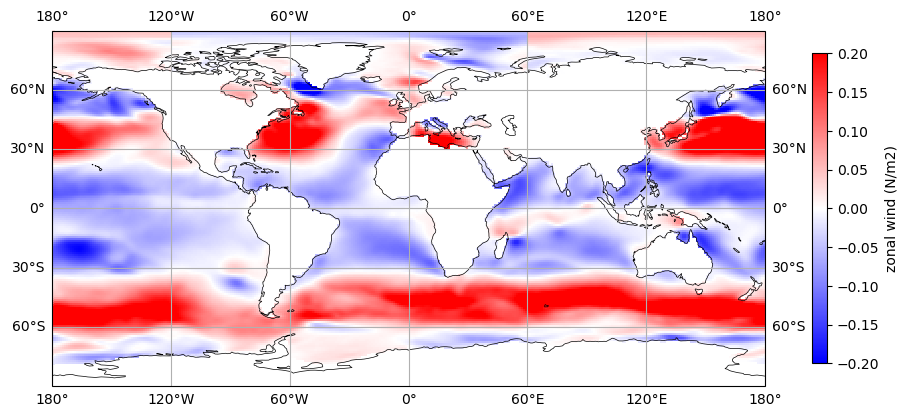

In [32]:
# Create a map
fig, ax = plt.subplots(
    figsize=(10, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
#ax.set_extent([0, 360, -90, 90], crs=ccrs.PlateCarree())

vmin, vmax = -0.2, 0.2

# Add coastlines and gridlines
ax.coastlines(resolution="110m", linewidth=0.5)
#ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=True)
c = plt.pcolormesh(tauuo.x, tauuo.y, tauuo[0,:,:], cmap="bwr", vmin=vmin, vmax=vmax)
cbar = plt.colorbar(c, ax=ax, orientation="vertical", fraction=0.02, pad=0.06) 
cbar.set_label("zonal wind (N/m2)", fontsize=10)
plt.show()

In [33]:
tauuo_ano = remove_climatology(tauuo)

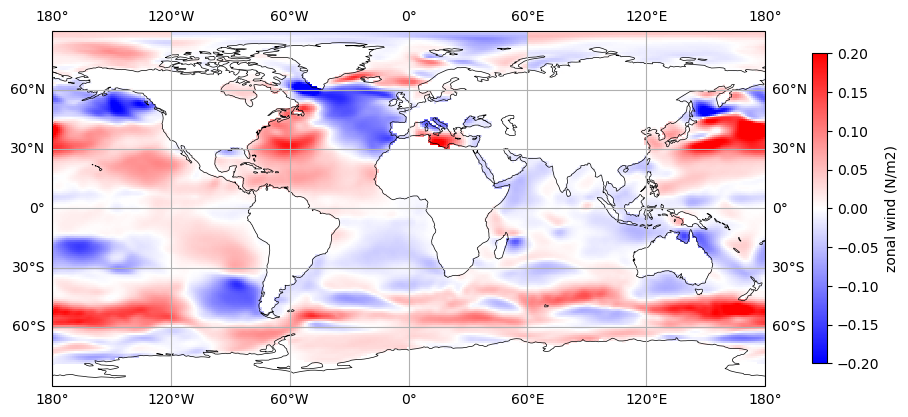

In [37]:
# Create a map
fig, ax = plt.subplots(
    figsize=(10, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
#ax.set_extent([0, 360, -90, 90], crs=ccrs.PlateCarree())

vmin, vmax = -0.2, 0.2

# Add coastlines and gridlines
ax.coastlines(resolution="110m", linewidth=0.5)
#ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=True)
c = plt.pcolormesh(tauuo.x, tauuo.y, tauuo_ano[0,:,:], cmap="bwr", vmin=vmin, vmax=vmax)
cbar = plt.colorbar(c, ax=ax, orientation="vertical", fraction=0.02, pad=0.06) 
cbar.set_label("zonal wind (N/m2)", fontsize=10)
plt.show()

In [38]:
tauuo_ano_zmean = tauuo_ano.weighted(data["areacello"]).mean(["x"]) #.transpose()

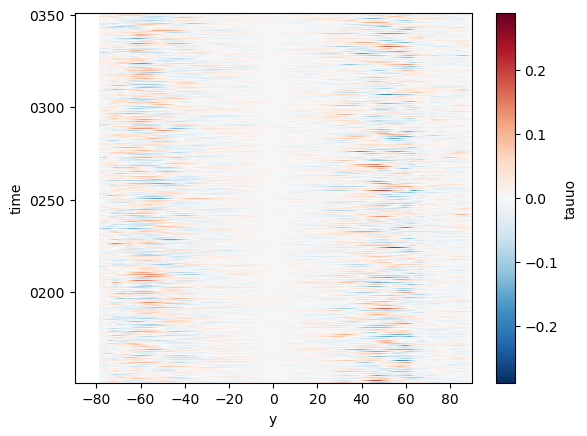

In [39]:
tauuo_ano_zmean.plot() #(cmap="coolwarm", vmin=-50, vmax=50)
plt.show()

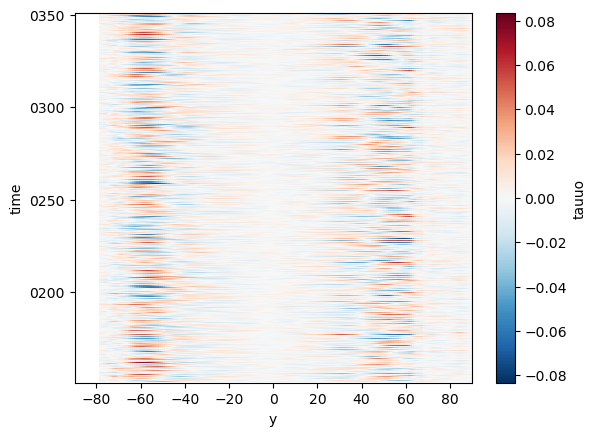

In [40]:
tauuo_ano_zmean.rolling(time=21, center=True).mean().plot() #(cmap="coolwarm", vmin=-50, vmax=50)
plt.show()

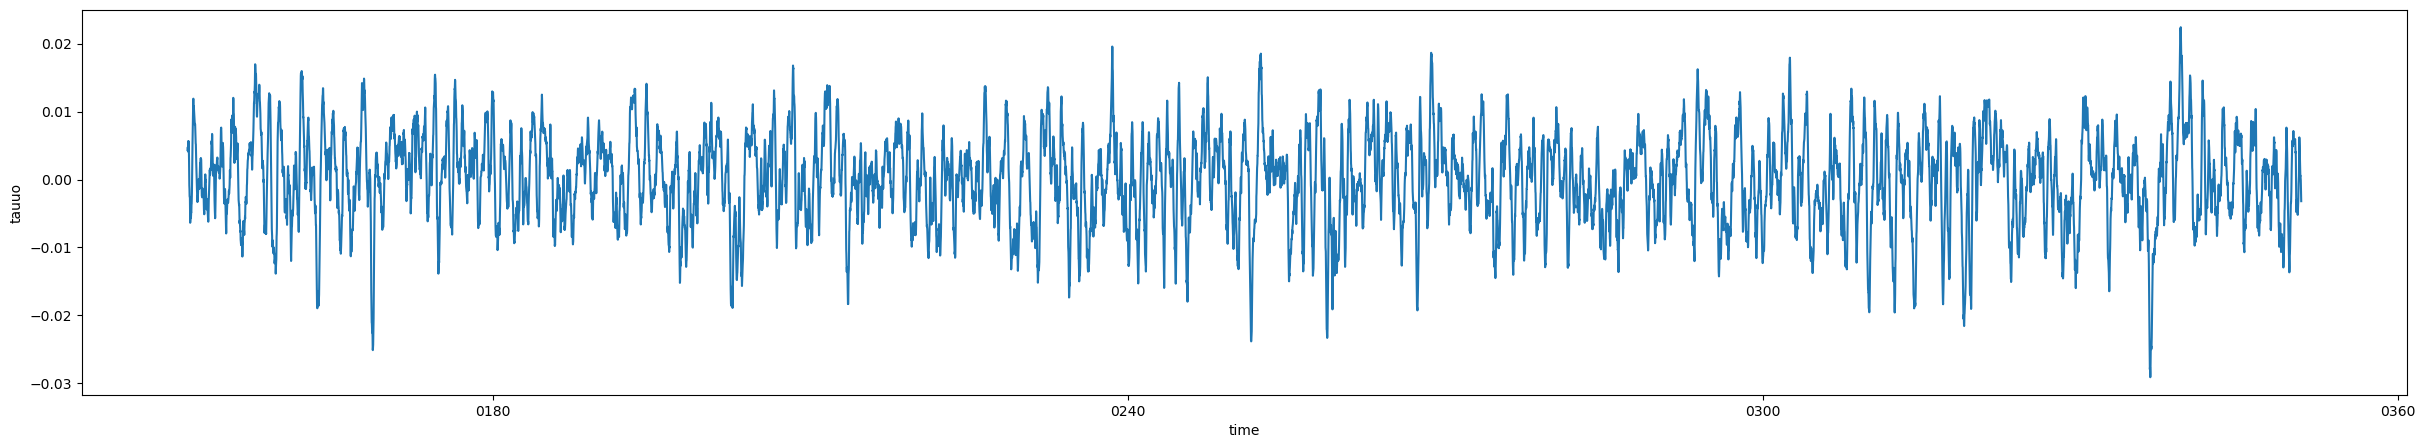

In [42]:
plt.figure(figsize=(30, 5)) 
tauuo_ano_zmean.sel(y=slice(-90, -30)).mean(["y"]).rolling(time=21, center=True).mean().plot()
plt.show()

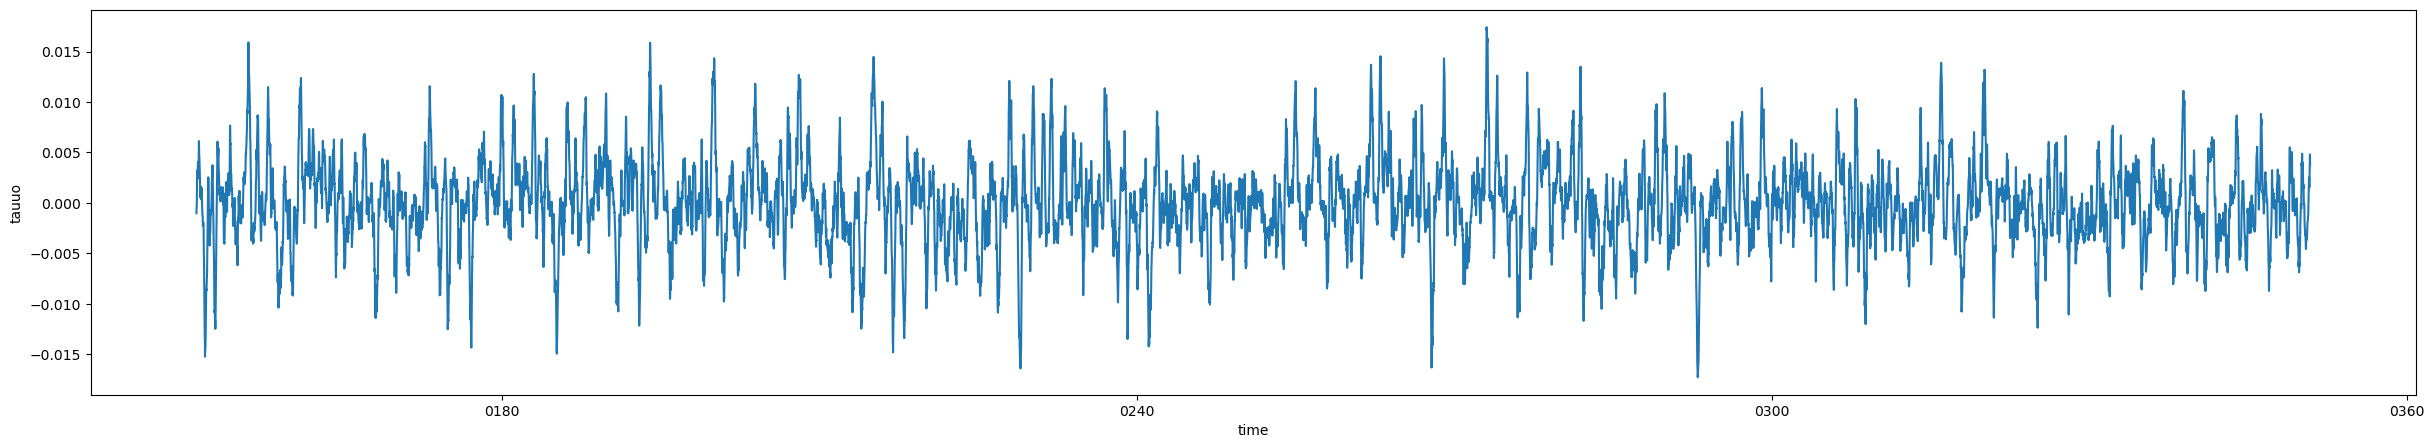

In [43]:
plt.figure(figsize=(30, 5)) 
tauuo_ano_zmean.sel(y=slice(30, 90)).mean(["y"]).rolling(time=21, center=True).mean().plot()
plt.show()